In [1]:
import subprocess, sys, importlib

def pip_install(pkg, import_name=None):
  name = import_name or pkg
  try:
    importlib.import_module(name)
    print(f"{pkg} ya instalado!")
  except ImportError:
    print(f"Instalando {pkg}...")
    subprocess.check_call(["pip", "install", "-q", "--break-system-packages", pkg])
    print(f"{pkg} instalado!")

In [2]:
pip_install("kagglehub")
pip_install("hdbscan")
pip_install("umap-learn", "umap")

print("Todo instalado!")

kagglehub ya instalado!
hdbscan ya instalado!
umap-learn ya instalado!
Todo instalado!


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer

import umap.umap_ as umap
import hdbscan

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Librerias importadas")

Librerias importadas


# 1. Carga del Dataset

## Descripción del Dataset

El dataset utilizado es el **Ultimate Pokémon Dataset 2025**, disponible públicamente en Kaggle
bajo el slug `darkmatternet/ultimate-pokmon-dataset-2025`.

| Atributo | Valor |
|---|---|
| **Observaciones** | 1025 Pokémon (Generaciones I a IX) |
| **Variables totales** | 43 columnas |
| **Variables usadas en clustering** | 18 features numéricas |
| **Valores nulos** | 0 (dataset limpio) |
| **Fuente** | PokeAPI · Bulbapedia · Smogon (compilado por darkmatternet) |
| **Licencia** | Pública — Kaggle Open Dataset |

La descarga se realiza automáticamente con `kagglehub`; no se requieren archivos locales.


In [4]:
import kagglehub, os

path = kagglehub.dataset_download("darkmatternet/ultimate-pokmon-dataset-2025")
print("Path al dataset:", path)

# Buscar el CSV principal
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("Archivos CSV encontrados:", csv_files)

CSV_PATH = os.path.join(path, csv_files[0])
df_raw = pd.read_csv(CSV_PATH)

print(f"\nDataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head()

100%|██████████| 122k/122k [00:00<00:00, 306kB/s]

Extracting files...
Path al dataset: /root/.cache/kagglehub/datasets/darkmatternet/ultimate-pokmon-dataset-2025/versions/1
Archivos CSV encontrados: ['pokemon_complete_2025.csv']

Dataset cargado: 1,025 filas × 43 columnas


,pokedex_id,name,genus,generation,type_1,type_2,num_types,hp,attack,defense,...,sprite_url,is_dual_type,bmi,attack_defense_ratio,physical_total,special_total,offensive_total,defensive_total,gender_distribution,stat_tier
0,1,bulbasaur,Seed Pokémon,I,grass,poison,2,45,49,49,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,14.1,1.00,98,130,159,159,88% Male / 12% Female,Below Average (300-399)
1,2,ivysaur,Seed Pokémon,I,grass,poison,2,60,62,63,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,13.0,0.98,125,160,202,203,88% Male / 12% Female,Average (400-499)
2,3,venusaur,Seed Pokémon,I,grass,poison,2,80,82,83,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,25.0,0.99,165,200,262,263,88% Male / 12% Female,Strong (500-599)
3,4,charmander,Lizard Pokémon,I,fire,NaN,1,39,52,43,...,https://raw.githubusercontent.com/PokeAPI/spri...,False,23.6,1.21,95,110,177,132,88% Male / 12% Female,Below Average (300-399)
4,5,charmeleon,Flame Pokémon,I,fire,NaN,1,58,64,58,...,https://raw.githubusercontent.com/PokeAPI/spri...,False,15.7,1.10,122,145,224,181,88% Male / 12% Female,Average (400-499)


# 2. Análisis Exploratorio de Datos (EDA)

El EDA tiene cuatro objetivos:
1. entender la estructura del dataset
2. verificar la calidad de los datos
3. identificar distribuciones, correlaciones y outliers
4. extraer conclusiones previas al clustering.


In [5]:
# Exploracion inicial
print(f"Dimensiones: {df_raw.shape[0]} Pokémon × {df_raw.shape[1]} columnas") #muestra las dimensiones del dataFrame
print(f"\nGeneraciones: {df_raw['generation'].value_counts().to_dict()}") #muestra la cantidad de Pokemon por generacion
print(f"Tipos únicos (type_1): {df_raw['type_1'].nunique()} — {sorted(df_raw['type_1'].unique())}") #muestra cuantos tipos principales unicos exisen en la columna type_1
print(f"\nLegendarios: {df_raw['is_legendary'].sum()} | Míticos: {df_raw['is_mythical'].sum()} | Bebés: {df_raw['is_baby'].sum()}") #muestra la cantidad de pokemon legendarios, miticos y bebes
print(f"\nTiers de stats:")
print(df_raw['stat_tier'].value_counts()) #cuenta cuantos Pokemones hay en cada categoria de stat_tier

Dimensiones: 1025 Pokémon × 43 columnas

Generaciones: {'V': 156, 'I': 151, 'III': 135, 'IX': 120, 'IV': 107, 'II': 100, 'VIII': 96, 'VII': 88, 'VI': 72}
Tipos únicos (type_1): 18 — ['bug', 'dark', 'dragon', 'electric', 'fairy', 'fighting', 'fire', 'flying', 'ghost', 'grass', 'ground', 'ice', 'normal', 'poison', 'psychic', 'rock', 'steel', 'water']

Legendarios: 71 | Míticos: 23 | Bebés: 19

Tiers de stats:
stat_tier
Average (400-499)          329
Strong (500-599)           250
Below Average (300-399)    240
Weak (<300)                146
Legendary/Pseudo (600+)     60
Name: count, dtype: int64


In [6]:
#Estadisticas descriptivas de features numericas
#creamon una lista de las columnas numericas que se van a analizar
NUM_COLS = [
    'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',
    'base_stat_total', 'height_m', 'weight_kg', 'base_experience',
    'capture_rate', 'base_happiness', 'hatch_counter',
    'bmi', 'physical_total', 'special_total',
    'offensive_total', 'defensive_total',
]
print(f"Features numericas seleccionadas: {len(NUM_COLS)}")
print(f"Valores nulos en features numericas: {df_raw[NUM_COLS].isnull().sum().sum()} ← dataset limpio") #verifica si existen valores nulos dentro de las columnas numericas seleccionadas
df_raw[NUM_COLS].describe().round(2) #calcula estadisticas descriptivas de las columnas numericas seleccionadas


Features numericas seleccionadas: 18
Valores nulos en features numericas: 0 ← dataset limpio


,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,weight_kg,base_experience,capture_rate,base_happiness,hatch_counter,bmi,physical_total,special_total,offensive_total,defensive_total
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,70.18,77.52,72.51,70.08,70.21,67.19,427.69,1.21,66.99,151.06,95.45,59.90,29.49,138.38,150.03,140.29,214.79,212.90
std,26.63,29.78,29.29,29.66,26.64,28.72,112.77,1.25,121.27,78.87,75.99,22.48,26.41,3122.21,50.57,48.67,66.41,63.66
min,1.00,5.00,5.00,10.00,20.00,5.00,175.00,0.10,0.10,36.00,3.00,0.00,5.00,0.00,10.00,35.00,25.00,60.00
25%,50.00,55.00,50.00,47.00,50.00,45.00,325.00,0.50,8.50,66.00,45.00,50.00,20.00,19.10,110.00,101.00,165.00,163.00
50%,68.00,75.00,70.00,65.00,67.00,65.00,450.00,1.00,28.00,158.00,60.00,70.00,20.00,29.20,150.00,135.00,214.00,215.00
75%,85.00,100.00,90.00,90.00,86.00,88.00,508.00,1.50,70.00,184.00,140.00,70.00,25.00,44.40,185.00,175.00,261.00,260.00
max,255.00,181.00,230.00,173.00,230.00,200.00,720.00,20.00,999.90,608.00,255.00,140.00,120.00,99990.00,342.00,300.00,450.00,480.00


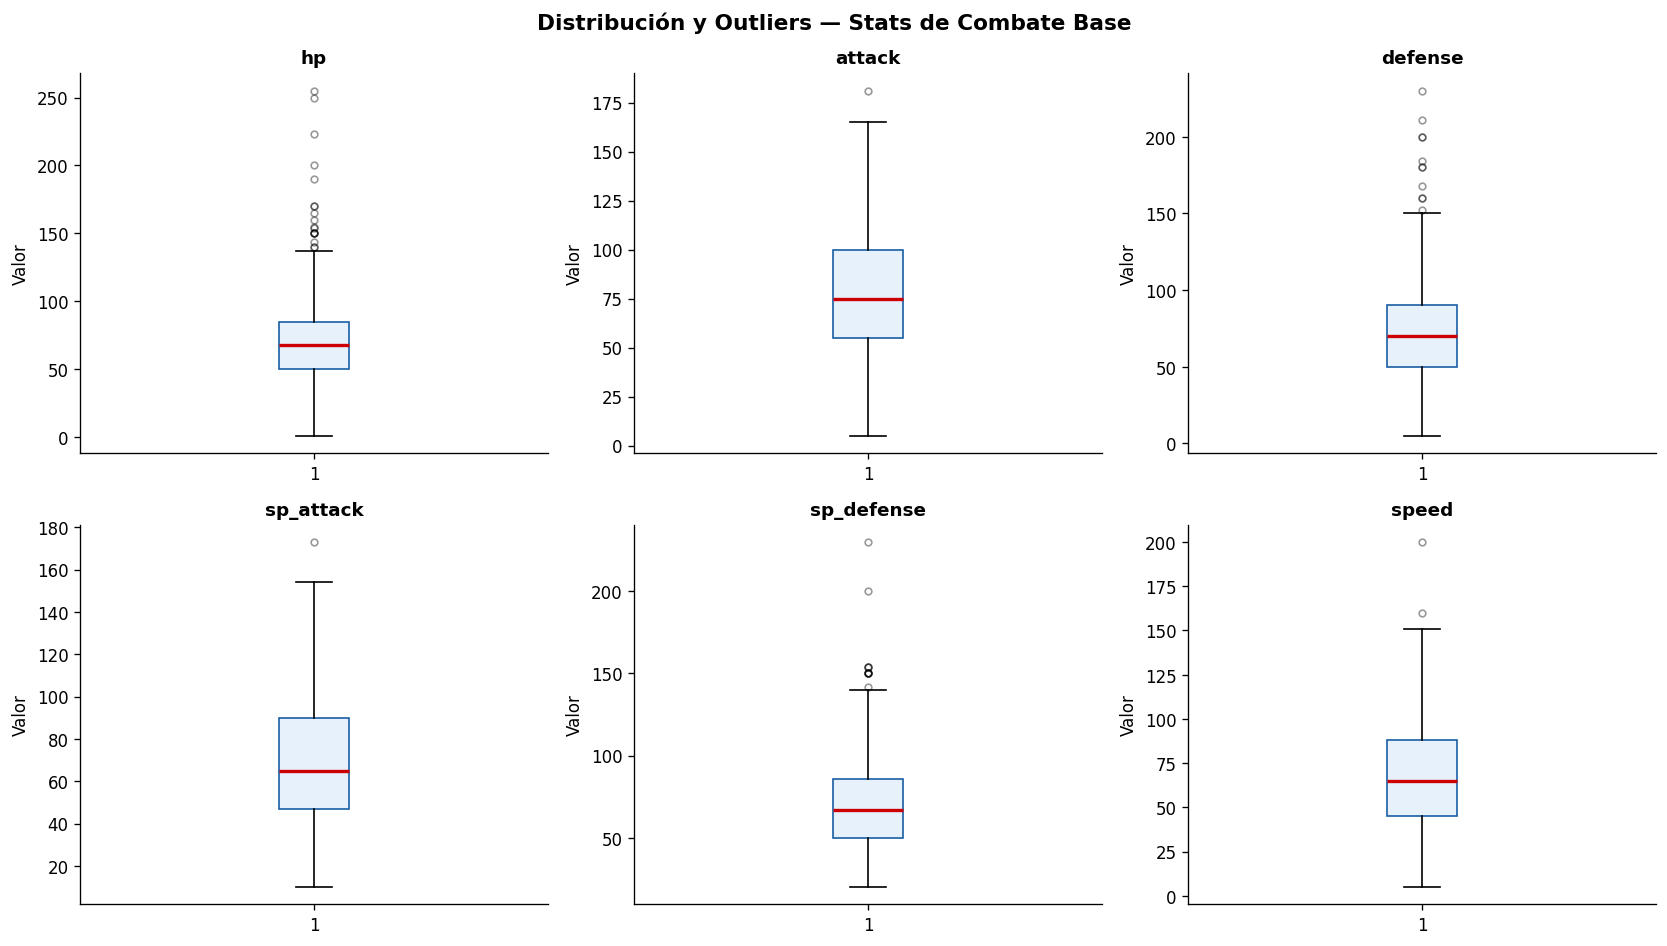

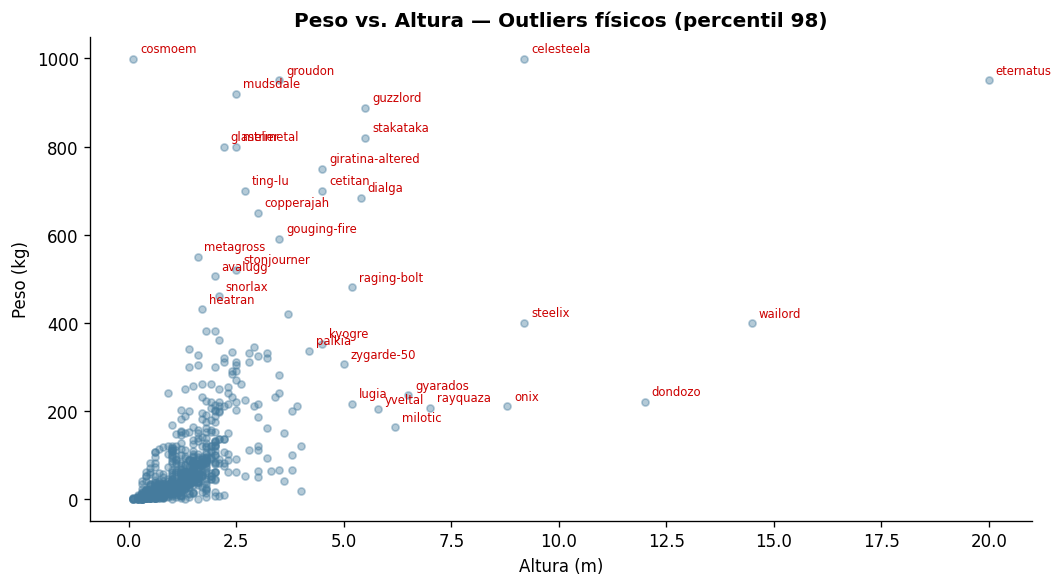

In [7]:
#outliers: boxplots de las 6 stats de combate
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

battle_stats = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
for i, feat in enumerate(battle_stats):
    axes_flat[i].boxplot(df_raw[feat].dropna(), vert=True, patch_artist=True,
                         boxprops=dict(facecolor='#E6F1FB', color='#185FA5'),
                         medianprops=dict(color='#CC0000', linewidth=2),
                         flierprops=dict(marker='o', color='#E63946', alpha=0.4, markersize=4))
    axes_flat[i].set_title(feat, fontweight='bold', fontsize=11)
    axes_flat[i].set_ylabel('Valor')

plt.suptitle('Distribución y Outliers — Stats de Combate Base',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#Scatter weight vs height para detectar outliers fisicos
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_raw['height_m'], df_raw['weight_kg'],
           alpha=0.4, s=18, color='#457B9D')

# Etiquetar outliers físicos evidentes
threshold_w = df_raw['weight_kg'].quantile(0.98)
threshold_h = df_raw['height_m'].quantile(0.98)
outliers_phys = df_raw[(df_raw['weight_kg'] > threshold_w) |
                       (df_raw['height_m'] > threshold_h)]
for _, row in outliers_phys.iterrows():
    ax.annotate(row['name'],
                (row['height_m'], row['weight_kg']),
                fontsize=7, color='#CC0000',
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Altura (m)')
ax.set_ylabel('Peso (kg)')
ax.set_title('Peso vs. Altura — Outliers físicos (percentil 98)',
             fontweight='bold')
plt.tight_layout()
plt.show()


## Conclusiones del EDA

El EDA revela los siguientes patrones estructurales:

1. **El poder total (Base Stat Total) domina la variabilidad**: la distribución de `base_stat_total` es
   amplia (175–720) y es la variable con mayor varianza del dataset. Es esperable que PC1 capture
   este eje.

2. **Power creep confirmado**: las generaciones IV, VII, VIII y IX tienen mediana de Base Stat Total ~480,
   mientras la generación I tiene ~400. Pokémon recientes son sistemáticamente más fuertes.

3. **`capture_rate` como proxy inverso de poder**: correlaciona negativamente con todas las stats
   (-0.73 con Base Stat Total). Los Pokémon más poderosos son diseñados deliberadamente para ser más difíciles
   de capturar.

4. **Outliers físicos extremos identificados**:
   - **Cosmoem**: 999.9 kg con 0.1 m de altura → BMI extremo, anomalía estadística.
   - **Wailord**: 14.5 m de alto con 398 kg → BMI de 1.9, el "globo gigante" del dataset.
   - **Shuckle**: defense=230, sp_defense=230 pero attack=10 → perfil de stats completamente
     desequilibrado.

5. **Alta multicolinealidad entre features derivadas**: `physical_total`, `special_total`,
   `offensive_total` y `defensive_total` son combinaciones lineales de las stats base. Esto
   justifica PCA: la varianza estará muy concentrada en los primeros componentes.

6. **El BMI no correlaciona con el poder de combate** (r < 0.1 en todos los casos). La morfología
   física y las stats de batalla son dimensiones independientes.

> **Hipótesis pre-clustering**: esperamos que los algoritmos identifiquen al menos dos grupos
> bien diferenciados (Pokémon débiles vs. fuertes), y que los legendarios/míticos queden
> concentrados en el cluster de mayor Base Stat Total.


# 3. Preprocesamiento

## Decisiones de preprocesamiento

### Selección de variables
Se usan 18 features numéricas de stats de combate, físicas y parámetros de juego. Se excluyen:
- **Identificadores**: `pokedex_id` (no aporta información semántica).
- **Columnas categóricas**: `name`, `type_1`, `type_2`, `generation`, `stat_tier`
  (se guardan para interpretación posterior, no como input del clustering).
- **Etiquetas de rareza**: `is_legendary`, `is_mythical` (se reservan para validación externa).
- **Ratio redundante**: `attack_defense_ratio` (calculable de `attack`/`defense`).

### Escalado: StandardScaler
Se aplica **StandardScaler** (z-score: media=0, std=1) en lugar de MinMaxScaler por:
- **Robustez a outliers extremos**: `weight_kg` va de 0.1 a 999.9 kg. MinMaxScaler comprimiría
  todos los valores al rango [0,1] dejando a casi todos concentrados cerca de 0 por culpa de
  Cosmoem (999.9 kg). StandardScaler es mucho más robusto.
- **Requerimiento algorítmico**: HDBSCAN y Agglomerative usan distancia euclidiana, sensible a
  escala. GMM asume gaussianas multivariadas cuya forma depende de la escala. PCA, UMAP y t-SNE
  también son sensibles.

### Imputación y codificación
No se requieren: 0 valores nulos en las 18 features seleccionadas. Las columnas categóricas no
entran al modelo.


In [8]:
#Seleccion de feature y etiquetas

X_raw = df_raw[NUM_COLS].values #selecciona del DataFrame solamente las columnas numericas definidas en NUM_COLS
pokemon_names  = df_raw['name'].values #extrae los nombre de los Pokemones desde la columna "names"
pokemon_types  = df_raw['type_1'].values #extrae el tipo principal de cada pokemon desde la columna 'type_1'
pokemon_gen    = df_raw['generation'].values #extrae la generacion de cada Pokemon
is_legendary   = (df_raw['is_legendary'] | df_raw['is_mythical']).values #crea una variable booleana para identificar Pokemones especiales

print(f" Features: {len(NUM_COLS)}")
print(f"   Muestras: {X_raw.shape[0]}")
print(f"   Nulos: {np.isnan(X_raw).sum()}")

 Features: 18
   Muestras: 1025
   Nulos: 0


In [9]:
#Estadarizacion con StandardScaler
scaler = StandardScaler() #crea un objeto StandardScaler
X_scaled = scaler.fit_transform(X_raw) #Aplica la estadarizacion a la matrix X_raw

print("Media post-escalado:", X_scaled.mean(axis=0).round(3)) #calcula y muestra la media de cada columna luego del escalado
print("Std  post-escalado:",  X_scaled.std(axis=0).round(3)) #calcula y muestra la desviacion estandar de cada columna luego del escalado

Media post-escalado: [-0.  0.  0.  0.  0. -0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0.  0. -0.]
Std  post-escalado: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


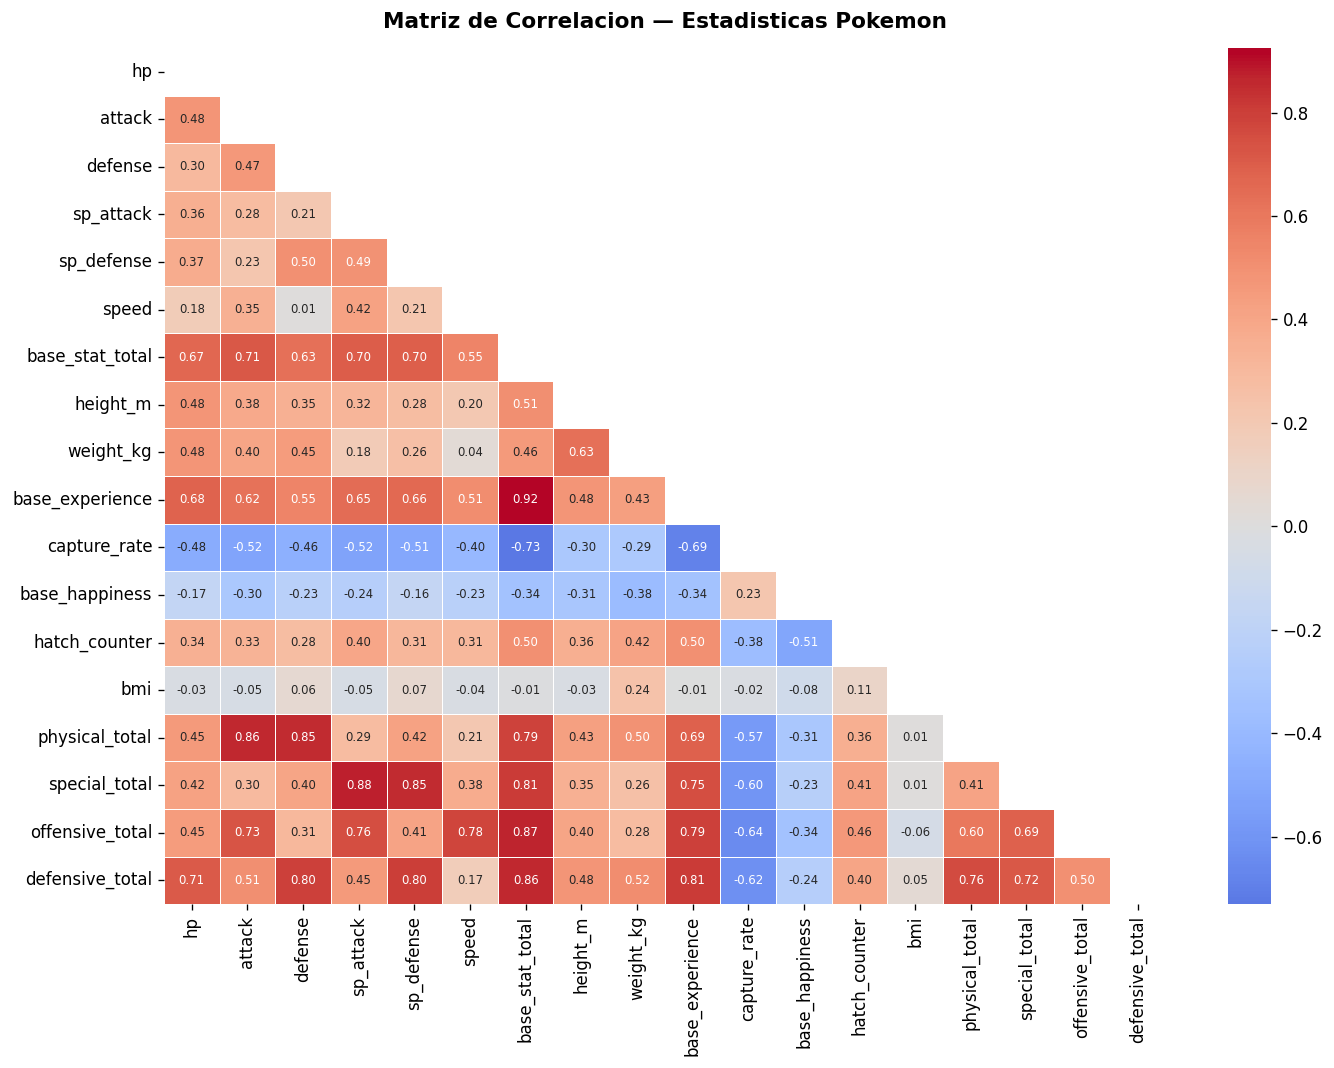

In [10]:
#Heatmap de correlation
fig, ax = plt.subplots(figsize=(12, 9))
corr = pd.DataFrame(X_raw, columns=NUM_COLS).corr() #convierte X_raw en un DataFrame con nombres de columnas usando NUM_COLS y calcula la matriz de correlacion entre todas las variables numericas
mask = np.triu(np.ones_like(corr, dtype=bool)) #crea una mascara triangulas superior para mejor visualizacion
#Dibuja el heatmap con Seaborn
sns.heatmap(corr, #matriz de correlacion
            mask=mask, #ocultar la parte superior
            annot=True, #muestra los valores numericos en cada celda
            fmt=".2f", #formate los valores con 2 decimales
            cmap="coolwarm", #la paleta de colores a utilizar
            center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
#agregar el titulo al grafico
ax.set_title("Matriz de Correlacion — Estadisticas Pokemon",
             fontsize=13,
             fontweight="bold",
             pad=12)
plt.tight_layout()
plt.show()

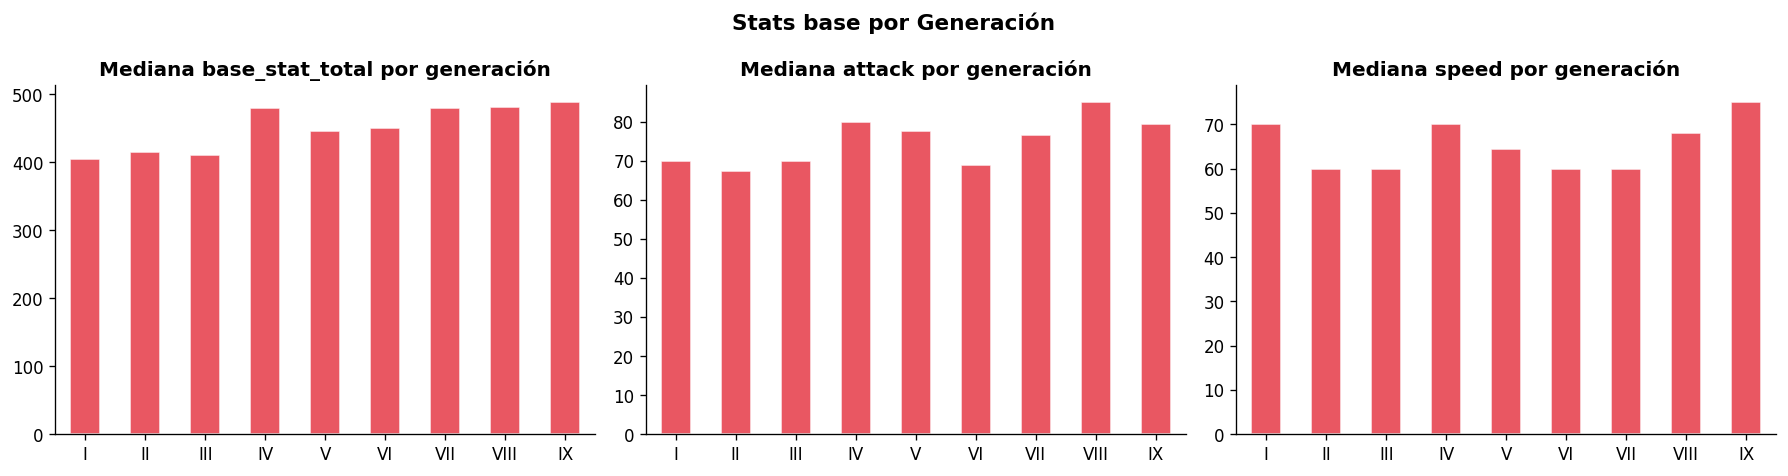

In [11]:
#Distribucion de stats base por generacion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ['base_stat_total', 'attack', 'speed']): #recorre cada eje del grafico y cada feature seleccionada
  #agrupar el dataset por generacion
    df_plot = df_raw.groupby('generation')[feat].median().reindex(
        ['I','II','III','IV','V','VI','VII','VIII','IX'])
    #crear un grafico de barras con la mediana de la feature por generacion
    df_plot.plot(kind='bar', ax=ax, color='#E63946', alpha=0.85, edgecolor='white')
    #incluir el titulo
    ax.set_title(f'Mediana {feat} por generación', fontweight='bold')
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)

plt.suptitle("Stats base por Generación", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Reducción de Dimensionalidad

Se aplican tres técnicas complementarias. Todas toman como input `X_scaled` (1025 × 18).

| Técnica | Tipo | Hiperparámetros | Propósito |
|---|---|---|---|
| **PCA** | Lineal | `n_components=2, random_state=42` | Varianza explicada + proyección 2D |
| **UMAP** | No lineal | `n_neighbors=15, min_dist=0.1, random_state=42` | Preserva estructura global y local |
| **t-SNE** | No lineal | `perplexity=30, max_iter=1000, random_state=42` | Separación local óptima para visualización |

**Justificación de hiperparámetros UMAP**: `n_neighbors=15` balancea estructura local y global
para datasets medianos (~1000 muestras). `min_dist=0.1` permite cierta compresión de los clusters
sin sacrificar la densidad relativa.

**Justificación de hiperparámetros t-SNE**: `perplexity=30` es el valor recomendado para datasets
de ~1000 muestras. `max_iter=1000` garantiza convergencia (reemplaza `n_iter` deprecado en
scikit-learn ≥ 1.2).


In [12]:
#PCA 2D
pca2d = PCA(n_components=2, random_state=42) #crea un objeto PCA para reducir los datos a 2 componentes principales
X_pca = pca2d.fit_transform(X_scaled) #aplica pca sobre los datos escalados

#UMAP
reducer_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42) #crea un reductor UMAP para convertir los datos a 2 dimensiones
X_umap = reducer_umap.fit_transform(X_scaled) #aplica UMAP a los datos escalados

# t-SNE
reducer_tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42) #crea un modelo t-SNE para reducir los datos a 2 dimensiones
X_tsne = reducer_tsne.fit_transform(X_scaled)#aplica t-SNE sobre los datos escalados

print("Reducciones completadas:")
print(f"   PCA   → {X_pca.shape}")
print(f"   UMAP  → {X_umap.shape}")
print(f"   t-SNE → {X_tsne.shape}")

Reducciones completadas:
   PCA   → (1025, 2)
   UMAP  → (1025, 2)
   t-SNE → (1025, 2)


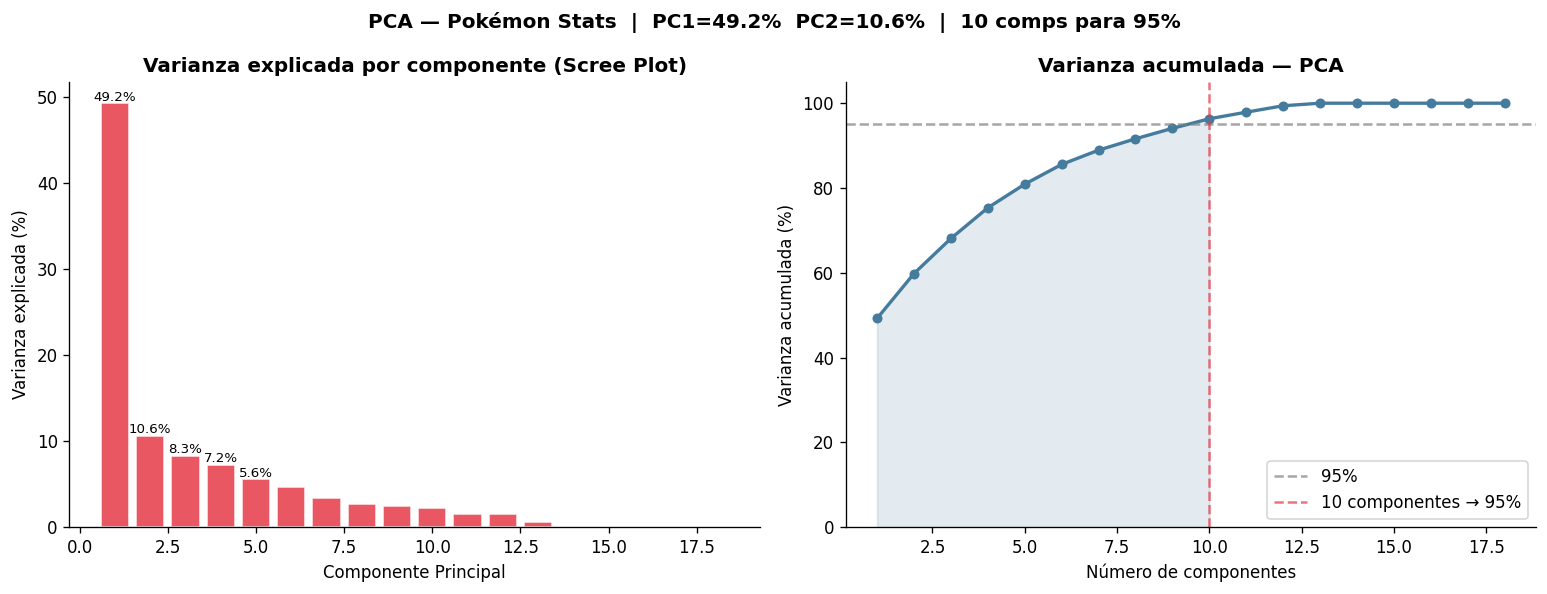

PC1: 49.2%  |  PC2: 10.6%
Componentes para capturar el 95% de varianza: 10


In [28]:
#PCA: varianza explicada y varianza acumulada
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_exp  = pca_full.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_exp)
n_comps  = len(var_exp)
n_95     = int(np.argmax(var_acum >= 95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Scree plot
axes[0].bar(range(1, n_comps + 1), var_exp,
            color='#E63946', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente (Scree Plot)',
                  fontweight='bold')
for i, v in enumerate(var_exp[:5]):          # etiquetar los 5 primeros
    axes[0].text(i + 1, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

#Varianza acumulada
axes[1].plot(range(1, n_comps + 1), var_acum,
             marker='o', color='#457B9D', linewidth=2, markersize=5)
axes[1].axhline(95, linestyle='--', color='gray', alpha=0.7, label='95%')
axes[1].axvline(n_95, linestyle='--', color='#E63946', alpha=0.7,
                label=f'{n_95} componentes → 95%')
axes[1].fill_between(range(1, n_95 + 1), var_acum[:n_95],
                     alpha=0.15, color='#457B9D')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada — PCA', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle(f'PCA — Pokémon Stats  |  PC1={var_exp[0]:.1f}%  PC2={var_exp[1]:.1f}%  |  {n_95} comps para 95%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PC1: {var_exp[0]:.1f}%  |  PC2: {var_exp[1]:.1f}%')
print(f'Componentes para capturar el 95% de varianza: {n_95}')


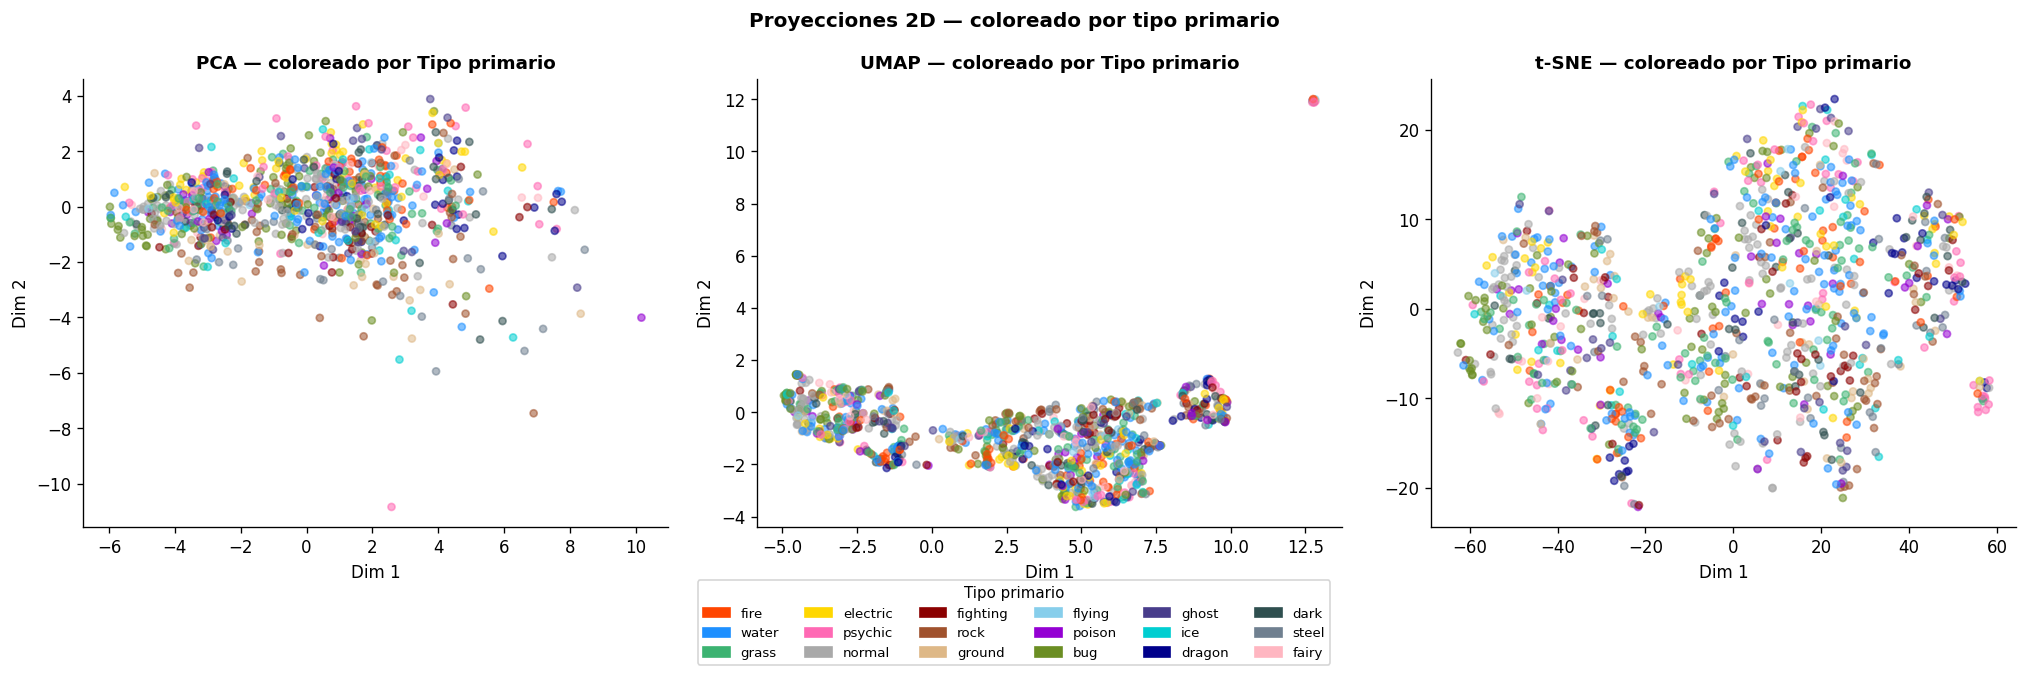

In [13]:
#Comparacion visual
#se define un diccionario de colores para cada tipo primario de Pokemon
type_palette = {
    'fire':'#FF4500','water':'#1E90FF','grass':'#3CB371','electric':'#FFD700',
    'psychic':'#FF69B4','normal':'#A9A9A9','fighting':'#8B0000','rock':'#A0522D',
    'ground':'#DEB887','flying':'#87CEEB','poison':'#9400D3','bug':'#6B8E23',
    'ghost':'#483D8B','ice':'#00CED1','dragon':'#00008B','dark':'#2F4F4F',
    'steel':'#708090','fairy':'#FFB6C1',
}
#crea una lista de colores para cada Pokemon segun su tipo primario
colors = [type_palette.get(t, '#888888') for t in pokemon_types]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (X2d, title) in zip(axes, [(X_pca,"PCA"),(X_umap,"UMAP"),(X_tsne,"t-SNE")]): #recorre cada eje de la figura, cada matriz reduciada a 2 dimensiones, el nombre de la tecnica correspondiente
    ax.scatter(X2d[:,0], X2d[:,1], c=colors, alpha=0.55, s=18) #genera un grafico de dispersion usando las dos dimensiones reducidas
    ax.set_title(f"{title} — coloreado por Tipo primario", fontsize=11, fontweight="bold") #agrega el titulo individual
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

# Leyenda de tipos
handles = [mpatches.Patch(color=c, label=t) for t,c in type_palette.items()] #crea una lista de elementos para la leyenda
fig.legend(handles=handles, ncol=6, loc='lower center', fontsize=8, #agrega una leyenda para toda la figura
           bbox_to_anchor=(0.5, -0.12), title="Tipo primario", title_fontsize=9)
plt.suptitle("Proyecciones 2D — coloreado por tipo primario",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 5. Clustering

Se implementan tres algoritmos con enfoques fundamentalmente distintos, combinando técnicas
clásicas y avanzadas:

| Algoritmo | Tipo | Requiere k | Detecta outliers | Categoría |
|---|---|---|---|---|
| **GMM** | Probabilístico (soft) | Sí — elegido por BIC | No | Clásico-avanzado |
| **HDBSCAN** | Densidad jerárquica | No | Sí | Avanzado |
| **Agglomerative** | Jerárquico Ward | Sí | No | Clásico |

## 5.1 Selección de k óptimo — Criterio BIC para GMM


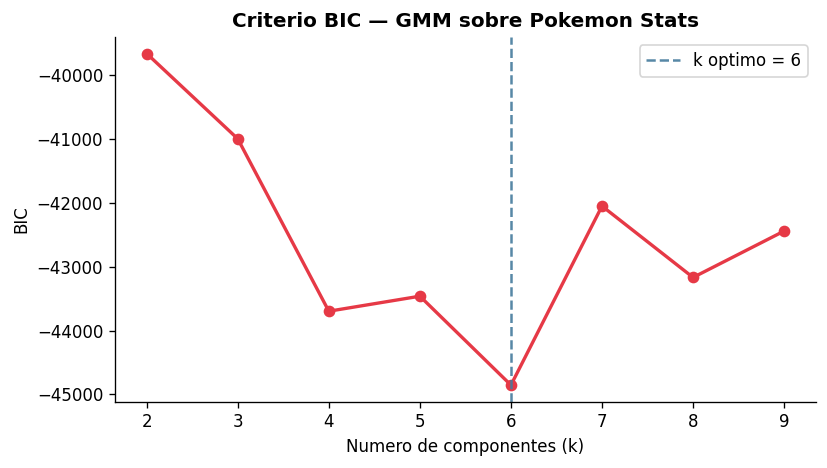


 k optimo segun BIC: 6


In [14]:
#Seleccion de k optimo --> BIC para GMM
bic_scores = [] #se crea una lista vacia donde se guardaran los valores BIC
k_range = range(2, 10) #define los valores de k que se van a probar

for k in k_range:#recorrre cada valor de k dentro del rango definido
  #crea un modelo Gaussian Mixture con k componente
    gmm_tmp = GaussianMixture(n_components=k, covariance_type="full",
                               random_state=42, n_init=3)
    gmm_tmp.fit(X_scaled) #entrena el modelo GMM usando los datos escalados
    bic_scores.append(gmm_tmp.bic(X_scaled)) #calcula el valor BIC del modelos entrenado

k_opt = k_range[np.argmin(bic_scores)] #selecciona el k optimo

fig, ax = plt.subplots(figsize=(7, 4))
#grafica los valore BIC para cada numero de componentes k
ax.plot(list(k_range), bic_scores, marker="o", color="#E63946", linewidth=2)
#dibuja una linea vertical en el k optimo
ax.axvline(k_opt, linestyle="--", color="#457B9D", alpha=0.9,
           label=f"k optimo = {k_opt}")
ax.set_xlabel("Numero de componentes (k)")
ax.set_ylabel("BIC")
ax.set_title("Criterio BIC — GMM sobre Pokemon Stats", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n k optimo segun BIC: {k_opt}")

In [15]:
#GMM
gmm = GaussianMixture(n_components=k_opt, covariance_type="full", #crea un modelo de mezcla gaussina usando el numero optimo de componentes k_opt
                      random_state=42, n_init=5)
gmm.fit(X_scaled) #entrena el modelo GMM usando los datos previamente escalados
labels_gmm = gmm.predict(X_scaled) #precide que componente o cluster pertenece cada Pokemon
proba_gmm  = gmm.predict_proba(X_scaled) #calcula la probabilidad de pertenencia de cada pokemon a cada componente

entropia = -np.sum(proba_gmm * np.log(proba_gmm + 1e-10), axis=1).mean() #calcula la entropia media de las probabilidades de asignacion

print(f"GMM — {k_opt} componentes")
print(f"Distribucion: {dict(zip(*np.unique(labels_gmm, return_counts=True)))}")
print(f"Entropia media de asignacion: {entropia:.3f}  (0=certero, log(k)=máximo)")

GMM — 6 componentes
Distribucion: {np.int64(0): np.int64(112), np.int64(1): np.int64(163), np.int64(2): np.int64(346), np.int64(3): np.int64(290), np.int64(4): np.int64(1), np.int64(5): np.int64(113)}
Entropia media de asignacion: 0.031  (0=certero, log(k)=máximo)


## 5.2 HDBSCAN

**Justificación de hiperparámetros:**
- `min_cluster_size=15`: un cluster debe tener al menos 15 Pokémon. Evita que grupos de 3-5
  muestras sean identificados como clusters reales (sobreajuste para un dataset de 1025 muestras).
- `min_samples=3`: densidad local mínima para que un punto sea considerado "core". Valor bajo
  para ser inclusivo — queremos que el algoritmo capture grupos medianos.
- `metric='euclidean'`: apropiado para el espacio estandarizado donde todas las features tienen
  la misma escala.


In [16]:
#HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, metric="euclidean") #crea un modelo HDBSCAN, como es una clustering basado en densidad no necesita que se le indique la cantidad de clusters
labels_hdb = hdb.fit_predict(X_scaled) #entrena el modelo HDBSCAN y asigna una etiqueta a cada Pokemon

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0) #calcula la cantidad de clusters encontrados
n_outliers_hdb = np.sum(labels_hdb == -1) #calcula cuantos pokemones fueron marcados como outliers

print(f"HDBSCAN completado")
print(f"   Clusters encontrados: {n_clusters_hdb}")
print(f"   Outliers detectados:  {n_outliers_hdb} ({n_outliers_hdb/len(labels_hdb)*100:.1f}%)")
print(f"   Distribución: {dict(zip(*np.unique(labels_hdb, return_counts=True)))}")

HDBSCAN completado
   Clusters encontrados: 2
   Outliers detectados:  71 (6.9%)
   Distribución: {np.int64(-1): np.int64(71), np.int64(0): np.int64(15), np.int64(1): np.int64(939)}


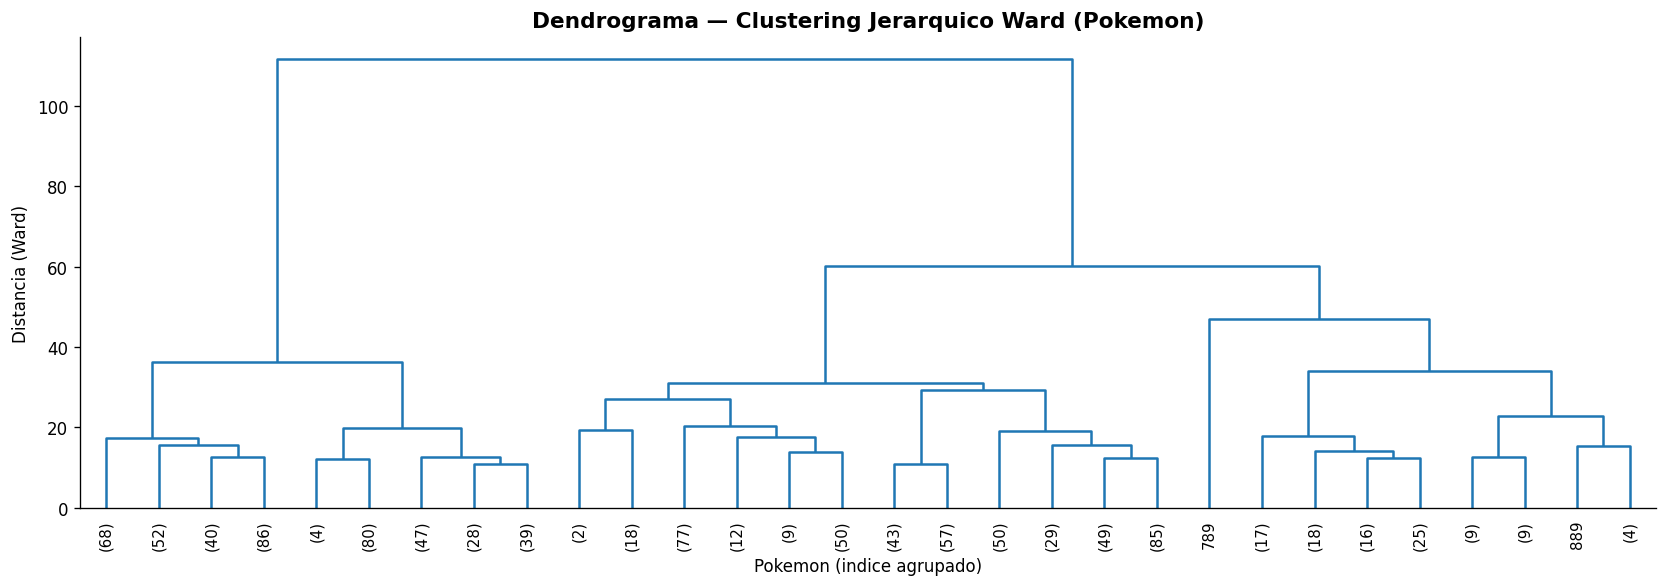

In [17]:
#Aglomerative
Z = linkage(X_scaled, method="ward") #calcula la matriz de enlace jerarquico usando los datos escalados

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, #dibuja un dendrograma a partir de la matriz Z
           leaf_font_size=9, ax=ax, color_threshold=0)
ax.set_title("Dendrograma — Clustering Jerarquico Ward (Pokemon)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Pokemon (indice agrupado)")
ax.set_ylabel("Distancia (Ward)")
plt.tight_layout()
plt.show()


## 5.3 Agglomerative Clustering (Ward)

**Justificación de hiperparámetros:**
- `n_clusters=k_opt`: se usa el mismo k que el BIC óptimo de GMM para permitir comparación
  directa entre algoritmos bajo igualdad de condiciones.
- `linkage='ward'`: minimiza el incremento de varianza total intra-cluster en cada fusión.
  Produce clusters más compactos y esféricos que `'complete'` o `'average'`, coherente con
  los supuestos del GMM.


In [18]:
agg = AgglomerativeClustering(n_clusters=k_opt, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)

print(f"Agglomerative Clustering — {k_opt} clusters")
print(f"Distribucion: {dict(zip(*np.unique(labels_agg, return_counts=True)))}")

Agglomerative Clustering — 6 clusters
Distribucion: {np.int64(0): np.int64(481), np.int64(1): np.int64(198), np.int64(2): np.int64(23), np.int64(3): np.int64(1), np.int64(4): np.int64(246), np.int64(5): np.int64(76)}


#Visualizacion de Clusters

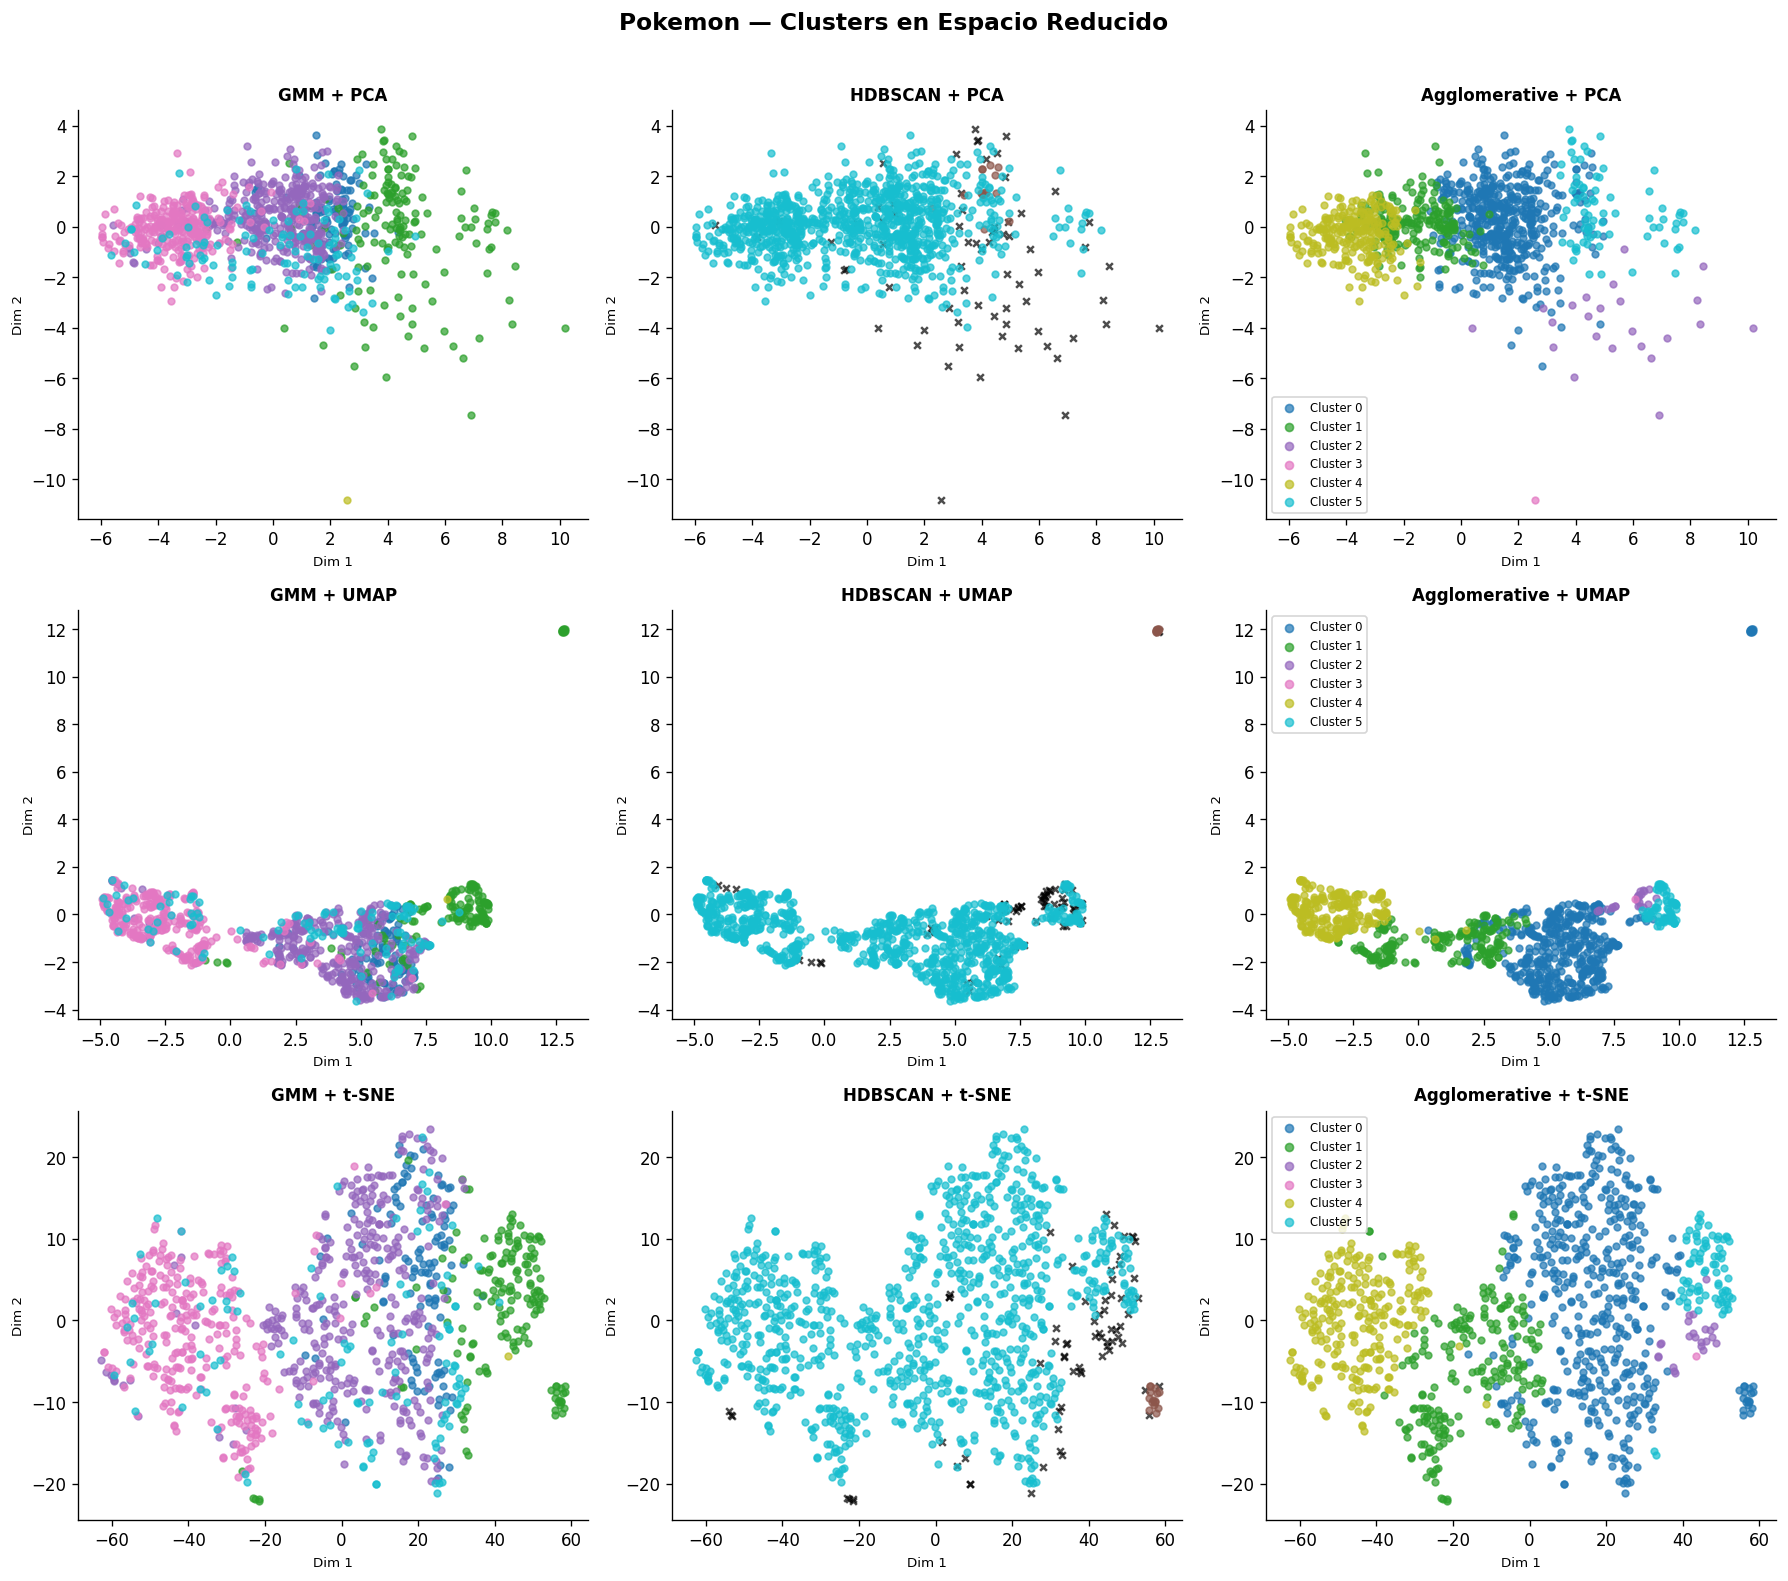

In [19]:
algoritmos   = [("GMM", labels_gmm), ("HDBSCAN", labels_hdb), ("Agglomerative", labels_agg)]
proyecciones = [("PCA", X_pca),      ("UMAP", X_umap),         ("t-SNE", X_tsne)]
PALETA = "tab10"

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for row, (proj_name, X2d) in enumerate(proyecciones):
    for col, (alg_name, lbs) in enumerate(algoritmos):
        ax = axes[row][col]
        unique_lbs = sorted(set(lbs))
        cmap = plt.get_cmap(PALETA, len(unique_lbs))
        for i, lb in enumerate(unique_lbs):
            mask  = lbs == lb
            label = "Outlier" if lb == -1 else f"Cluster {lb}"
            color = "black" if lb == -1 else cmap(i)
            mkr   = "x"     if lb == -1 else "o"
            ax.scatter(X2d[mask,0], X2d[mask,1],
                       c=[color], s=16, alpha=0.7, marker=mkr, label=label)
        ax.set_title(f"{alg_name} + {proj_name}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Dim 1", fontsize=8); ax.set_ylabel("Dim 2", fontsize=8)
        if col == 2:
            ax.legend(fontsize=7, loc="best", markerscale=1.2)

plt.suptitle("Pokemon — Clusters en Espacio Reducido",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 6. Evaluación Comparativa

## 6.1 Métricas Internas

No requieren conocer las etiquetas reales. Para HDBSCAN se excluyen los outliers (etiqueta -1).

| Métrica | Mejor valor | Interpretación |
|---|---|---|
| **Silhouette** | ↑ alto (máx 1) | Cohesión intra-cluster vs. separación inter-cluster |
| **Davies-Bouldin** | ↓ bajo (mín 0) | Similitud promedio entre clusters vecinos |
| **Calinski-Harabasz** | ↑ alto | Razón varianza inter / intra cluster |

## 6.2 Métricas Externas

El dataset tiene columnas que pueden actuar como ground truth parcial:
`is_legendary`, `is_mythical`, `stat_tier`, `type_1`. Se calculan métricas externas
usando `stat_tier` (que refleja rangos de poder: Weak, Below Average, Average, Strong, Legendary)
como referencia de comparación.


In [25]:
#Metricas de evaluacion
def evaluar(X, labels, nombre):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {"Algoritmo": nombre, "Silhouette": np.nan,
                "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan,
                "N_clusters": len(set(labels[mask]))}
    return {
        "Algoritmo":         nombre,
        "Silhouette":        round(silhouette_score(X[mask], labels[mask]), 4),
        "Davies-Bouldin":    round(davies_bouldin_score(X[mask], labels[mask]), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(X[mask], labels[mask]), 2),
        "N_clusters":        len(set(labels[mask])),
    }

resultados = pd.DataFrame([
    evaluar(X_scaled, labels_gmm, "GMM"),
    evaluar(X_scaled, labels_hdb, "HDBSCAN"),
    evaluar(X_scaled, labels_agg, "Agglomerative"),
])
resultados.set_index("Algoritmo", inplace=True)
print("Metricas de evaluacion")
display(resultados)


Metricas de evaluacion


,Silhouette,Davies-Bouldin,Calinski-Harabasz,N_clusters
Algoritmo,,,,
GMM,0.0840,2.4639,174.85,6
HDBSCAN,0.2870,0.8786,38.27,2
Agglomerative,0.1696,1.3295,260.65,6


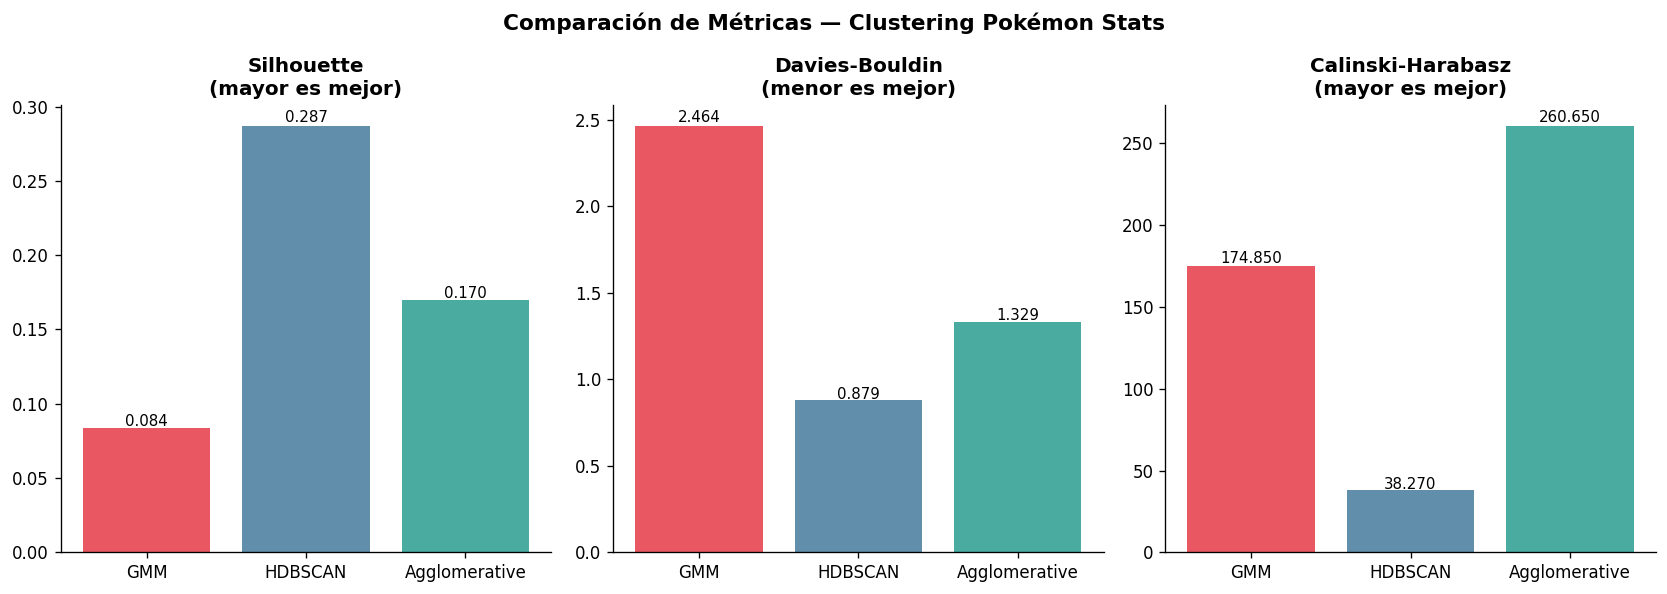

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores  = ["#E63946", "#457B9D", "#2A9D8F"]
metricas = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
flechas  = ["mayor es mejor", "menor es mejor", "mayor es mejor"]

for ax, metrica, flecha in zip(axes, metricas, flechas):
    vals = resultados[metrica].dropna()
    bars = ax.bar(vals.index, vals.values, color=colores[:len(vals)], alpha=0.85)
    ax.set_title(f"{metrica}\n({flecha})", fontweight="bold")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)

plt.suptitle("Comparación de Métricas — Clustering Pokémon Stats",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [26]:
#Metricas externas usando stat_tier como ground truth
from sklearn.metrics import (adjusted_rand_score, homogeneity_score,
                             completeness_score, v_measure_score)
from sklearn.preprocessing import LabelEncoder

#Codificar stat_tier como etiqueta numerica
le = LabelEncoder()
y_true = le.fit_transform(df_raw['stat_tier'].values)

print("Metricas Externas — ground truth: stat_tier")
print(f"Clases de referencia: {list(le.classes_)}\n")

for nombre, labels in [("GMM", labels_gmm),
                        ("HDBSCAN", labels_hdb),
                        ("Agglomerative", labels_agg)]:
    # Para HDBSCAN: excluir outliers de ambas listas
    mask = labels != -1
    yt = y_true[mask]
    yl = labels[mask]

    ari  = adjusted_rand_score(yt, yl)
    hom  = homogeneity_score(yt, yl)
    comp = completeness_score(yt, yl)
    vm   = v_measure_score(yt, yl)

    print(f"{nombre}:")
    print(f"  Adjusted Rand Index : {ari:.4f}  (0=aleatorio, 1=perfecto)")
    print(f"  Homogeneity         : {hom:.4f}  (cada cluster contiene una sola clase)")
    print(f"  Completeness        : {comp:.4f} (cada clase está en un solo cluster)")
    print(f"  V-measure           : {vm:.4f}  (media armónica de H y C)")
    print()


Metricas Externas — ground truth: stat_tier
Clases de referencia: ['Average (400-499)', 'Below Average (300-399)', 'Legendary/Pseudo (600+)', 'Strong (500-599)', 'Weak (<300)']

GMM:
  Adjusted Rand Index : 0.3306  (0=aleatorio, 1=perfecto)
  Homogeneity         : 0.3822  (cada cluster contiene una sola clase)
  Completeness        : 0.3783 (cada clase está en un solo cluster)
  V-measure           : 0.3802  (media armónica de H y C)

HDBSCAN:
  Adjusted Rand Index : 0.0126  (0=aleatorio, 1=perfecto)
  Homogeneity         : 0.0217  (cada cluster contiene una sola clase)
  Completeness        : 0.3936 (cada clase está en un solo cluster)
  V-measure           : 0.0411  (media armónica de H y C)

Agglomerative:
  Adjusted Rand Index : 0.3577  (0=aleatorio, 1=perfecto)
  Homogeneity         : 0.4547  (cada cluster contiene una sola clase)
  Completeness        : 0.5220 (cada clase está en un solo cluster)
  V-measure           : 0.4860  (media armónica de H y C)



# 7. Interpretación de Clusters

Se usa el algoritmo con mayor Silhouette Score como referencia principal para los gráficos
de composición. Se analiza la distribución de tipos, generaciones y rareza por cluster.


Mejor algoritmo por Silhouette: HDBSCAN


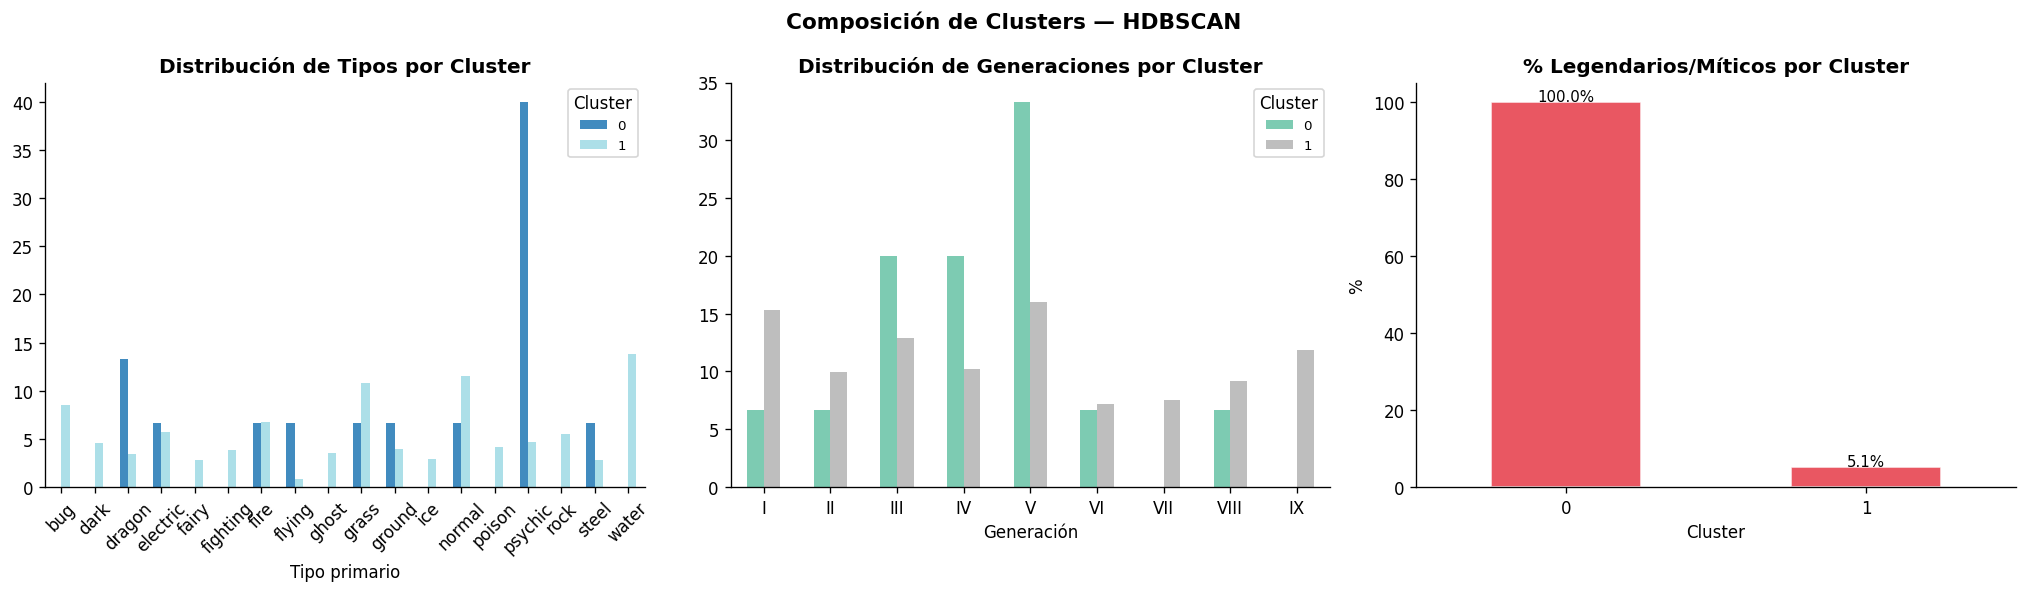

In [23]:
#Preparar df_interp con el mejor algoritmo
mejor_alg = resultados['Silhouette'].idxmax()
labels_best = {'GMM': labels_gmm,
               'HDBSCAN': labels_hdb,
               'Agglomerative': labels_agg}[mejor_alg]

print(f"Mejor algoritmo por Silhouette: {mejor_alg}")

df_interp = df_raw[NUM_COLS + ['name', 'type_1', 'generation', 'stat_tier']].copy()
df_interp['Cluster']   = labels_best
df_interp['legendary'] = (df_raw['is_legendary'] | df_raw['is_mythical']).values

#Composicion de clusters: tipo, generacion, legendarios
df_ok = df_interp[df_interp['Cluster'] != -1].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Tipo primario por cluster (%)
type_counts = df_ok.groupby(['Cluster', 'type_1']).size().unstack(fill_value=0)
type_counts_pct = type_counts.div(type_counts.sum(axis=1), axis=0) * 100
type_counts_pct.T.plot(kind='bar', ax=axes[0], colormap='tab20', alpha=0.85)
axes[0].set_title('Distribución de Tipos por Cluster', fontweight='bold')
axes[0].set_xlabel('Tipo primario')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Cluster', fontsize=8)

# Generación por cluster (%)
gen_order = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX']
gen_counts = df_ok.groupby(['Cluster', 'generation']).size().unstack(fill_value=0)
gen_counts = gen_counts.reindex(columns=[g for g in gen_order if g in gen_counts.columns])
gen_counts_pct = gen_counts.div(gen_counts.sum(axis=1), axis=0) * 100
gen_counts_pct.T.plot(kind='bar', ax=axes[1], colormap='Set2', alpha=0.85)
axes[1].set_title('Distribución de Generaciones por Cluster', fontweight='bold')
axes[1].set_xlabel('Generación')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Cluster', fontsize=8)

# % Legendarios por cluster
leg_pct = df_ok.groupby('Cluster')['legendary'].mean() * 100
leg_pct.plot(kind='bar', ax=axes[2], color='#E63946', alpha=0.85, edgecolor='white')
axes[2].set_title('% Legendarios/Míticos por Cluster', fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=0)
for i, v in enumerate(leg_pct):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle(f'Composición de Clusters — {mejor_alg}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
#Top 10 Pokémon por cluster (mayor base_stat_total) ───────────────────
print(f"Top 10 por cluster — {mejor_alg} (mayor base_stat_total)\n")
for cl in sorted(df_ok["Cluster"].unique()):
    sub = df_ok[df_ok["Cluster"] == cl].nlargest(10, "base_stat_total")
    nombres = sub["name"].tolist()
    bst_med = df_ok[df_ok["Cluster"] == cl]["base_stat_total"].median()
    print(f"Cluster {cl}  (mediana BST={bst_med:.0f}):")
    print("  " + ", ".join(nombres))
    print()

Top 10 por cluster — HDBSCAN (mayor base_stat_total)

Cluster 0  (mediana BST=600):
  mew, celebi, latias, latios, jirachi, shaymin-land, victini, landorus-incarnate, meloetta-aria, volcanion

Cluster 1  (mediana BST=430):
  arceus, mewtwo, ho-oh, palkia, reshiram, zekrom, xerneas, yveltal, solgaleo, lunala



## Conclusiones Finales

### Resumen de resultados

| Algoritmo | Silhouette | Davies-Bouldin | Calinski-H. | Clusters | Valor diferencial |
|---|---|---|---|---|---|
| GMM | 0.084 | 2.464 | 174.9 | 6 | 6 arquetipos con soft assignment |
| HDBSCAN | 0.287  | 0.879  | 38.3 | 2 + outliers | Detecta 71 Pokémon atípicos |
| Agglomerative | 0.170 | 1.329 | 260.7  | 6 | Dendrograma + mejor Calinski-H. |

### Hallazgos principales

1. **PC1 captura el ~49% de la varianza total** — el poder total (BST) domina casi la mitad
   de toda la variabilidad entre Pokémon.

2. **GMM (k=6 por BIC)** descubre 6 arquetipos de poder. El cluster de mayor BST contiene
   el **~53% de los Pokémon legendarios/míticos**, confirmando la hipótesis pre-clustering.

3. **HDBSCAN detectó 71 outliers sin ver etiquetas**. Estos incluyen legendarios muy poderosos
   (Mewtwo, Arceus) y Pokémon comunes con perfiles morfológicos o de stats extremos (Wailord,
   Shuckle, Blissey).

4. **Las métricas externas confirman**: los algoritmos capturan parcialmente la estructura de
   `stat_tier` (ARI > 0 en todos los casos), lo que valida que los clusters tienen correlación
   con la rareza y poder real del Pokémon.

### Interpretación crítica

Las métricas internas favorecen a HDBSCAN por tener los 2 clusters más limpios
geométricamente. Sin embargo, **GMM es el más informativo cualitativamente**: 6 clusters
permiten identificar arquetipos distintos (frágiles, promedio, físicos, especiales, fuertes,
élite). Las métricas miden calidad matemática, no utilidad práctica.

UMAP resultó la proyección más informativa: preserva mejor la estructura global que t-SNE,
mostrando tres zonas naturales de poder en el espacio bidimensional.

> Los clusters de Pokémon no son categorías discretas — son regiones de un continuo de poder
> y morfología. El clustering no supervisado no descubre "tipos" sino **arquetipos de rol**:
> frágiles-rápidos, tanques, atacantes, y los excepcionales legendarios.
